In [1]:

###############################################################################
#             Unidade 2: Modelos de regularizacao ou penalidade               #
#                         Secao 2.2: Regressao Ridge                          # 
###############################################################################

RANDOM_SEED <- 42

# Vamos evitar a notacao cientifica nos resultados
options(scipen = 999)

## Instala pacotes necessários (instala apenas os ausentes, sem prompt)
required_pkgs <- c("yarrr", "plyr", "readr", "dplyr", "caret", "ggplot2", "repr", "glmnet", "fastDummies", "tidyverse")
install_if_missing <- function(pkgs) {
  missing <- pkgs[!sapply(pkgs, requireNamespace, quietly = TRUE)]
  if(length(missing)) install.packages(missing, repos = "https://cloud.r-project.org")
}
install_if_missing(required_pkgs)


In [2]:
# Carregando os pacotes necessarios
library(plyr)
library(readr)
library(dplyr)
library(caret)
library(ggplot2)
library(repr)
library(glmnet)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:plyr’:

    arrange, count, desc, failwith, id, mutate, rename, summarise,
    summarize


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Loading required package: lattice

Loading required package: Matrix

Loaded glmnet 5.0



In [3]:
# Carrega o arquivo .RData e atribui o primeiro objeto carregado a 'dat'
loaded_names <- load("trabalhosalarios.RData")
dat <- get(loaded_names[1])
# Mostrar quais objetos foram carregados (debug)
print(loaded_names)

View(dat)

[1] "trabalhosalarios"


,husage,husunion,husearns,huseduc,husblck,hushisp,hushrs,kidge6,earns,age,black,educ,hispanic,union,exper,kidlt6,lwage
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3,56,0,1500,14,0,0,40,1,100,49,0,12,0,0,31,0,1.897120
13,31,0,800,17,0,0,40,0,480,29,0,14,0,0,9,0,2.484907
20,33,0,950,13,0,0,60,0,455,30,0,12,0,0,12,1,2.431418
21,34,0,1000,14,0,0,50,1,102,31,0,12,0,0,13,0,1.629241
22,42,0,730,14,0,0,40,1,300,41,0,12,0,0,23,0,2.302585
25,45,0,1154,16,0,0,38,1,425,45,0,18,0,0,21,0,2.496741
26,33,0,1350,16,0,0,40,0,770,32,0,12,0,0,14,0,2.957511
27,31,0,769,18,0,0,55,0,125,27,0,14,0,0,7,1,1.783791
29,31,0,340,12,0,0,40,0,245,30,0,15,0,0,9,1,1.945910


In [4]:
# Vamos visualizar parte do dataset
glimpse(dat)

Rows: 2,574
Columns: 17
$ husage   <dbl> 56, 31, 33, 34, 42, 45, 33, 31, 31, 44, 45, 22, 66, 43, 26, 3…
$ husunion <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0…
$ husearns <dbl> 1500, 800, 950, 1000, 730, 1154, 1350, 769, 340, 750, 1200, 2…
$ huseduc  <dbl> 14, 17, 13, 14, 14, 16, 16, 18, 12, 12, 12, 12, 16, 12, 14, 1…
$ husblck  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ hushisp  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ hushrs   <dbl> 40, 40, 60, 50, 40, 38, 40, 55, 40, 40, 50, 40, 40, 50, 36, 5…
$ kidge6   <dbl> 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0…
$ earns    <dbl> 100, 480, 455, 102, 300, 425, 770, 125, 245, 539, 300, 299, 5…
$ age      <dbl> 49, 29, 30, 31, 41, 45, 32, 27, 30, 42, 42, 23, 55, 31, 27, 3…
$ black    <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ educ     <dbl> 12, 14, 12, 12, 12, 18, 12, 14, 15, 12, 12, 13, 12, 12, 14, 1…
$ hispanic <dbl>

In [5]:
# Checar valores faltantes no dataset 'dat'
na_count <- sum(is.na(dat))

if (na_count > 0) {
  cat("Há", na_count, "valores faltantes\n")
  # Contagem de NA por coluna
  print(sapply(dat, function(x) sum(is.na(x))))
} else {
  cat("Não há valores faltantes\n")
}


Não há valores faltantes


In [6]:
library(fastDummies)

# Transformando colunas  em variaveis dummy (categóricas) 

#1. Transformar em colunas dummies ( “quebrar” a categoria em números 0/1 para o modelo enxergar.)
#Finalidade:
#deixar a variável utilizável por modelos que só aceitam números, como glmnet;
#evitar dar uma ordem falsa para categorias;
#representar cada categoria separadamente no modelo.

#2. Transformar em factor (usado no ElasticNet)
#informar ao R/caret que a variável é qualitativa;
#fazer com que a interface por fórmula trate essa coluna como categoria e gere a codificação apropriada internamente;
#preservar o significado categórico durante o ajuste, especialmente quando você usa train(..., method = "glmnet") com fórmula.

dat <- dummy_cols(dat, select_columns = c("husunion", "husblck", "hushisp", "kidge6", "black", "hispanic", "union", "kidlt6"), 
                        remove_most_frequent_dummy=FALSE, 
                        remove_selected_columns=TRUE)
str(dat)

'data.frame':	2574 obs. of  25 variables:
 $ husage    : num  56 31 33 34 42 45 33 31 31 44 ...
 $ husearns  : num  1500 800 950 1000 730 ...
 $ huseduc   : num  14 17 13 14 14 16 16 18 12 12 ...
 $ hushrs    : num  40 40 60 50 40 38 40 55 40 40 ...
 $ earns     : num  100 480 455 102 300 425 770 125 245 539 ...
 $ age       : num  49 29 30 31 41 45 32 27 30 42 ...
 $ educ      : num  12 14 12 12 12 18 12 14 15 12 ...
 $ exper     : num  31 9 12 13 23 21 14 7 9 24 ...
 $ lwage     : num  1.9 2.48 2.43 1.63 2.3 ...
 $ husunion_0: int  1 1 1 1 1 1 1 1 1 1 ...
 $ husunion_1: int  0 0 0 0 0 0 0 0 0 0 ...
 $ husblck_0 : int  1 1 1 1 1 1 1 1 1 1 ...
 $ husblck_1 : int  0 0 0 0 0 0 0 0 0 0 ...
 $ hushisp_0 : int  1 1 1 1 1 1 1 1 1 1 ...
 $ hushisp_1 : int  0 0 0 0 0 0 0 0 0 0 ...
 $ kidge6_0  : int  0 1 1 0 0 0 1 1 1 0 ...
 $ kidge6_1  : int  1 0 0 1 1 1 0 0 0 1 ...
 $ black_0   : int  1 1 1 1 1 1 1 1 1 1 ...
 $ black_1   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ hispanic_0: int  1 1 1 1 1 1 1 1 1 1 

In [7]:
# As colunas dummy precisam continuar numericas para o glmnet.
str(dat)


'data.frame':	2574 obs. of  25 variables:
 $ husage    : num  56 31 33 34 42 45 33 31 31 44 ...
 $ husearns  : num  1500 800 950 1000 730 ...
 $ huseduc   : num  14 17 13 14 14 16 16 18 12 12 ...
 $ hushrs    : num  40 40 60 50 40 38 40 55 40 40 ...
 $ earns     : num  100 480 455 102 300 425 770 125 245 539 ...
 $ age       : num  49 29 30 31 41 45 32 27 30 42 ...
 $ educ      : num  12 14 12 12 12 18 12 14 15 12 ...
 $ exper     : num  31 9 12 13 23 21 14 7 9 24 ...
 $ lwage     : num  1.9 2.48 2.43 1.63 2.3 ...
 $ husunion_0: int  1 1 1 1 1 1 1 1 1 1 ...
 $ husunion_1: int  0 0 0 0 0 0 0 0 0 0 ...
 $ husblck_0 : int  1 1 1 1 1 1 1 1 1 1 ...
 $ husblck_1 : int  0 0 0 0 0 0 0 0 0 0 ...
 $ hushisp_0 : int  1 1 1 1 1 1 1 1 1 1 ...
 $ hushisp_1 : int  0 0 0 0 0 0 0 0 0 0 ...
 $ kidge6_0  : int  0 1 1 0 0 0 1 1 1 0 ...
 $ kidge6_1  : int  1 0 0 1 1 1 0 0 0 1 ...
 $ black_0   : int  1 1 1 1 1 1 1 1 1 1 ...
 $ black_1   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ hispanic_0: int  1 1 1 1 1 1 1 1 1 1 

In [8]:
# Vamos jogar a semente para gerar numeros aleatorios
# Aqui no exemplo a semente eh "5", mas poderia
# ser qualquer outro numero, se todos usarem a mesma
# semente os resultados serao iguais.
# Essa semente de numeros aleatorios serve para
# particionar o dataset aleatoriamente
set.seed(RANDOM_SEED)  

# Vamos criar um indice para particionar o dataset em
# 50% para treinamento
index = sample(1:nrow(dat),0.5*nrow(dat))

# Vamos criar a base de dados de treinamento
train = dat[index,]  

# Vamos criar a base de dados de teste
test = dat[-index,] 

# Vamos checar as dimensoes das bases de treinamento e 
# teste
dim(train)
dim(test)
# A base de treinamento possui 75 linhas e 
# 10 colunas (variaveis)
# A base de teste possui 75 linhas e 10
# colunas (variaveis)

[1] 1287   25

[1] 1287   25

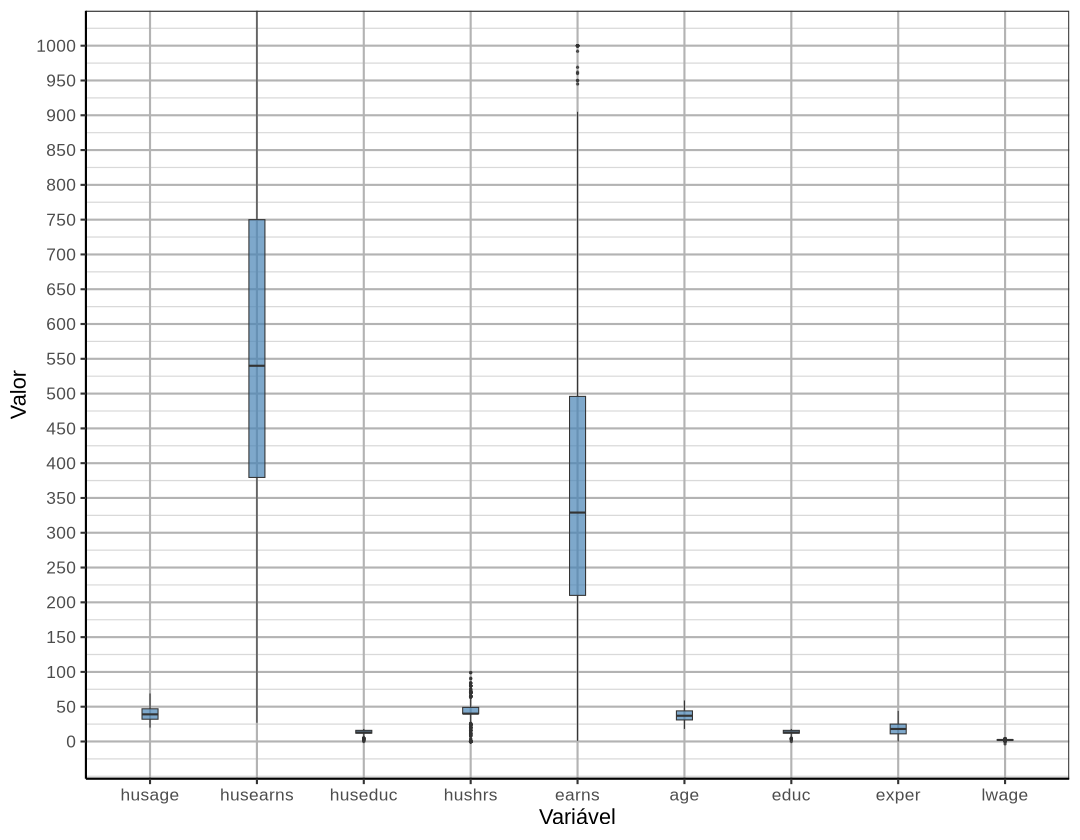

In [9]:
# Mostra um boxplot por variável para comparar escalas
# Facilita pra decidir se é necessário padronizar as variáveis

# Do enunciado, a variável dependente é "lwage" (log do salário), ou seja, já está padronizada

# Amplia só um pouco o tamanho do gráfico na saída do notebook
options(repr.plot.width = 9, repr.plot.height = 7)

train[, c("husage", "husearns", "huseduc", "hushrs", "earns", "age", "educ", "exper", "lwage")] %>%  # escolhe colunas
  stack() %>%  # coloca em formato longo (variável/valor)
  ggplot(aes(x = ind, y = values)) +  # inicia o gráfico
  geom_boxplot(fill = "steelblue", alpha = 0.7, width = 0.15, linewidth = 0.3, outlier.size = 0.3) +  # desenha boxplots
  coord_cartesian(ylim = c(NA, 1000)) +
  scale_y_continuous(breaks = seq(0, 1000, by = 50)) +
  labs(x = "Variável", y = "Valor") +  # rótulos dos eixos
  theme_bw(base_size = 13) +
  theme(
    axis.line = element_line(color = "black"),
    panel.grid.major = element_line(color = "grey70", linewidth = 0.6),
    panel.grid.minor = element_line(color = "grey85", linewidth = 0.35)
  )

In [10]:
# Padronizando com z-score apenas os preditores numéricos: husage, husearns, huseduc, hushrs, earns, age, educ, exper.

# incluir lwage na padronização?
# se padronizar , lembrar de no final despadronizar e fazer exp(lwage)
cols <- c("husage", "husearns", "huseduc", "hushrs", "earns", "age", "educ", "exper", "lwage")
pre_proc_val <- caret::preProcess(train[,cols], 
                           method = c("center", "scale")) # calcula média e desvio-padrão para cada coluna selecionada.

train1 <- train # necessário para criar uma cópia do dataset original e aplicar a padronização apenas nas colunas selecionadas, mantendo as outras colunas inalteradas.
train1[,cols] <- predict(pre_proc_val, train[,cols]) # realiza a padronização de fato nas colunas selecionadas

View(train1)


,husage,husearns,huseduc,hushrs,earns,age,educ,exper,lwage,husunion_0,⋯,kidge6_0,kidge6_1,black_0,black_1,hispanic_0,hispanic_1,union_0,union_1,kidlt6_0,kidlt6_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
2369,-1.11227857,-1.16855618,-2.0408595,-0.3215968,-0.7101031,-1.16799090,-1.8698485,-0.65845620,-1.04059341,1,⋯,1,0,1,0,0,1,1,0,0,1
1177,-0.31020404,-1.44973132,-0.5575410,-2.9704046,-0.6674872,-0.73681004,-0.6136305,-0.55508549,-0.75297339,1,⋯,0,1,0,1,1,0,1,0,1,0
1098,-1.11227857,-0.60620591,-0.5575410,-0.1702364,-0.8805668,-0.19783396,-0.6136305,-0.03823190,-1.01818124,1,⋯,0,1,1,0,1,0,1,0,1,0
1252,1.39420434,1.09564360,0.5549478,-0.3215968,-0.3734373,1.74247994,0.2238482,1.61569956,-0.18302060,0,⋯,1,0,1,0,1,0,1,0,1,0
634,0.09083323,0.34091034,-0.5575410,-0.1702364,0.5044506,-0.09003874,-0.6136305,0.06513881,0.23791160,1,⋯,1,0,1,0,1,0,1,0,0,1
2097,0.09083323,1.62543675,0.9257774,2.1001702,-0.2626359,0.01775648,-0.6136305,0.16850953,-0.01988423,1,⋯,0,1,1,0,1,0,1,0,1,0
1152,-1.01201925,-0.84298497,0.9257774,-0.1702364,-0.4970235,-0.52121961,-0.6136305,-0.34834405,-0.63614415,1,⋯,1,0,1,0,1,0,1,0,0,1
1327,0.29135186,1.61359779,1.6674366,-0.1702364,2.4434750,-0.19783396,1.4800663,-0.55508549,1.81770173,0,⋯,0,1,0,1,1,0,0,1,1,0
2072,-0.91175994,-1.05016665,-0.5575410,-0.1702364,-0.5566858,-0.73681004,1.8988056,-1.17530979,-0.48809125,1,⋯,1,0,1,0,1,0,1,0,1,0


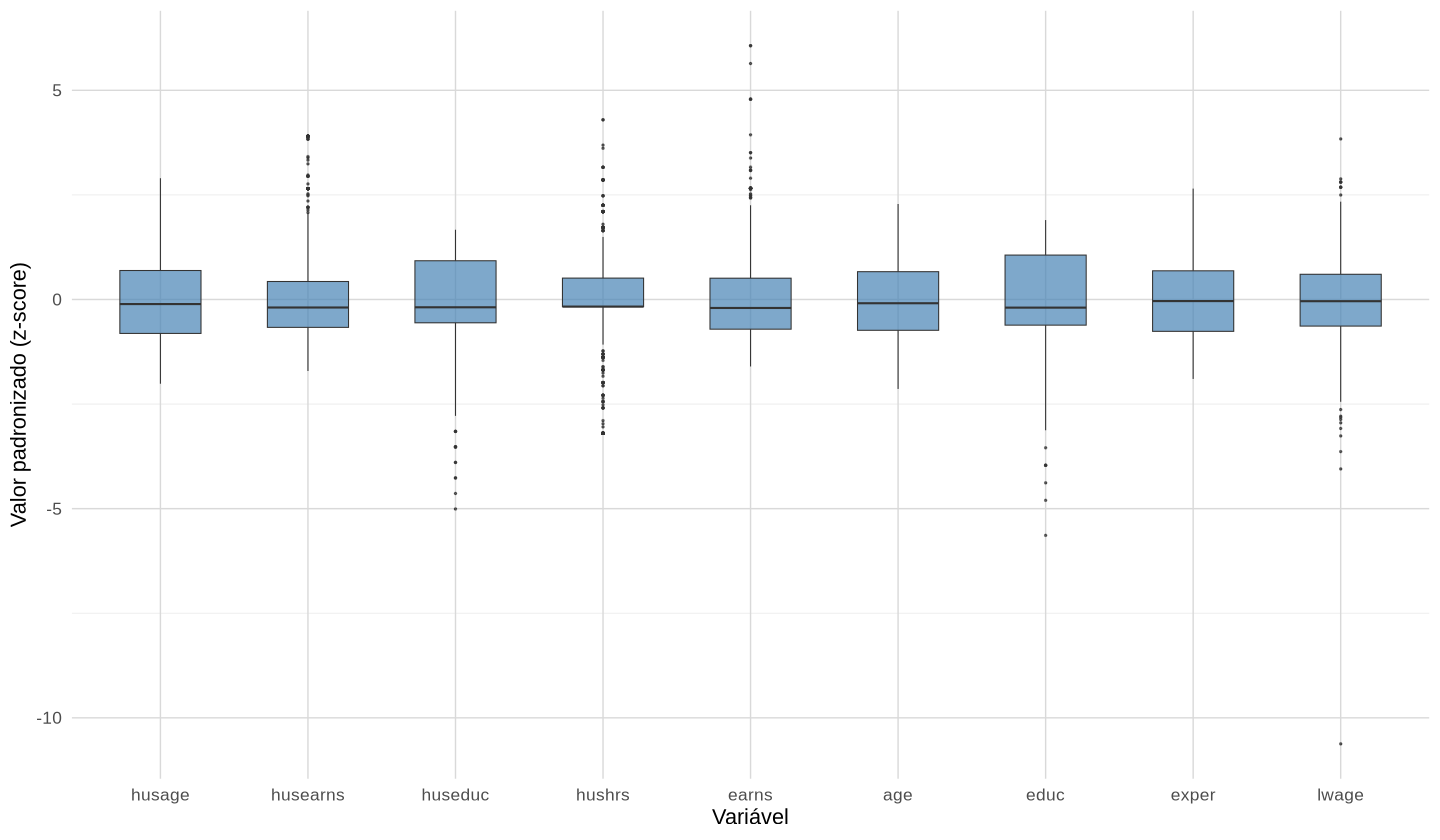

In [11]:
# Verificando os boxplots após a padronização, para confirmar que as variáveis numéricas estão na mesma escala.

 # Amplia só um pouco o tamanho do gráfico na saída do notebook
options(repr.plot.width = 12, repr.plot.height = 7)

train1[, c("husage", "husearns", "huseduc", "hushrs", "earns", "age", "educ", "exper", "lwage")] %>%  # escolhe colunas
  stack() %>%  # coloca em formato longo (variável/valor)
  ggplot(aes(x = ind, y = values)) +  # inicia o gráfico com um único eixo x e um único eixo y
  geom_boxplot(fill = "steelblue", alpha = 0.7, width = 0.55, linewidth = 0.3, outlier.size = 0.3) +  # desenha boxplots
  labs(x = "Variável", y = "Valor padronizado (z-score)") +  # rótulos dos eixos
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.major = element_line(color = "grey85", linewidth = 0.4),
    panel.grid.minor = element_line(color = "grey92", linewidth = 0.25)
  )

In [12]:
# Padronizando a base de teste usando os parâmetros calculados na base de treino
test1 <- test
test1[,cols] <- predict(pre_proc_val, test[,cols]) # aplica centro e escala calculados em 'train'


View(test1)

,husage,husearns,huseduc,hushrs,earns,age,educ,exper,lwage,husunion_0,⋯,kidge6_0,kidge6_1,black_0,black_1,hispanic_0,hispanic_1,union_0,union_1,kidlt6_0,kidlt6_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
5,0.19109254,0.37050772,0.1841182,-0.1702364,-0.32655980,0.34114213,-0.6136305,0.4786217,0.17963806,1,⋯,0,1,1,0,1,0,1,0,1,0
7,-0.71124130,2.20554545,0.9257774,-0.1702364,1.67638843,-0.62901482,-0.6136305,-0.4517148,1.41988427,1,⋯,1,0,1,0,1,0,1,0,1,0
9,-0.91175994,-0.78379021,-0.5575410,-0.1702364,-0.56094736,-0.84460525,0.6425876,-0.9685684,-0.49580437,1,⋯,1,0,1,0,1,0,1,0,0,1
15,-1.41305652,-0.25103732,0.1841182,-0.4729573,-0.13478816,-1.16799090,0.2238482,-1.1753098,-0.10048094,1,⋯,1,0,1,0,1,0,1,0,1,0
18,-0.20994472,2.64950619,0.9257774,-0.1702364,0.73883820,0.01775648,1.0613269,-0.2449733,0.78270065,1,⋯,1,0,1,0,1,0,1,0,0,1
20,1.39420434,-0.90217974,1.6674366,1.3433680,0.09959940,1.52688951,1.8988056,0.9954753,-0.24293221,1,⋯,1,0,1,0,1,0,0,1,1,0
23,-0.20994472,-1.07976404,1.6674366,0.4352054,0.09959940,-0.19783396,1.0613269,-0.4517148,0.17963806,1,⋯,0,1,1,0,1,0,1,0,1,0
24,0.39161118,2.50151928,1.6674366,-0.1702364,3.08271379,0.77232299,1.8988056,0.2718802,2.09532670,1,⋯,0,1,1,0,1,0,1,0,1,0
28,-0.61098199,3.90147548,1.6674366,1.3433680,2.49461409,-0.52121961,1.8988056,-0.9685684,2.58578493,1,⋯,1,0,1,0,0,1,1,0,0,1


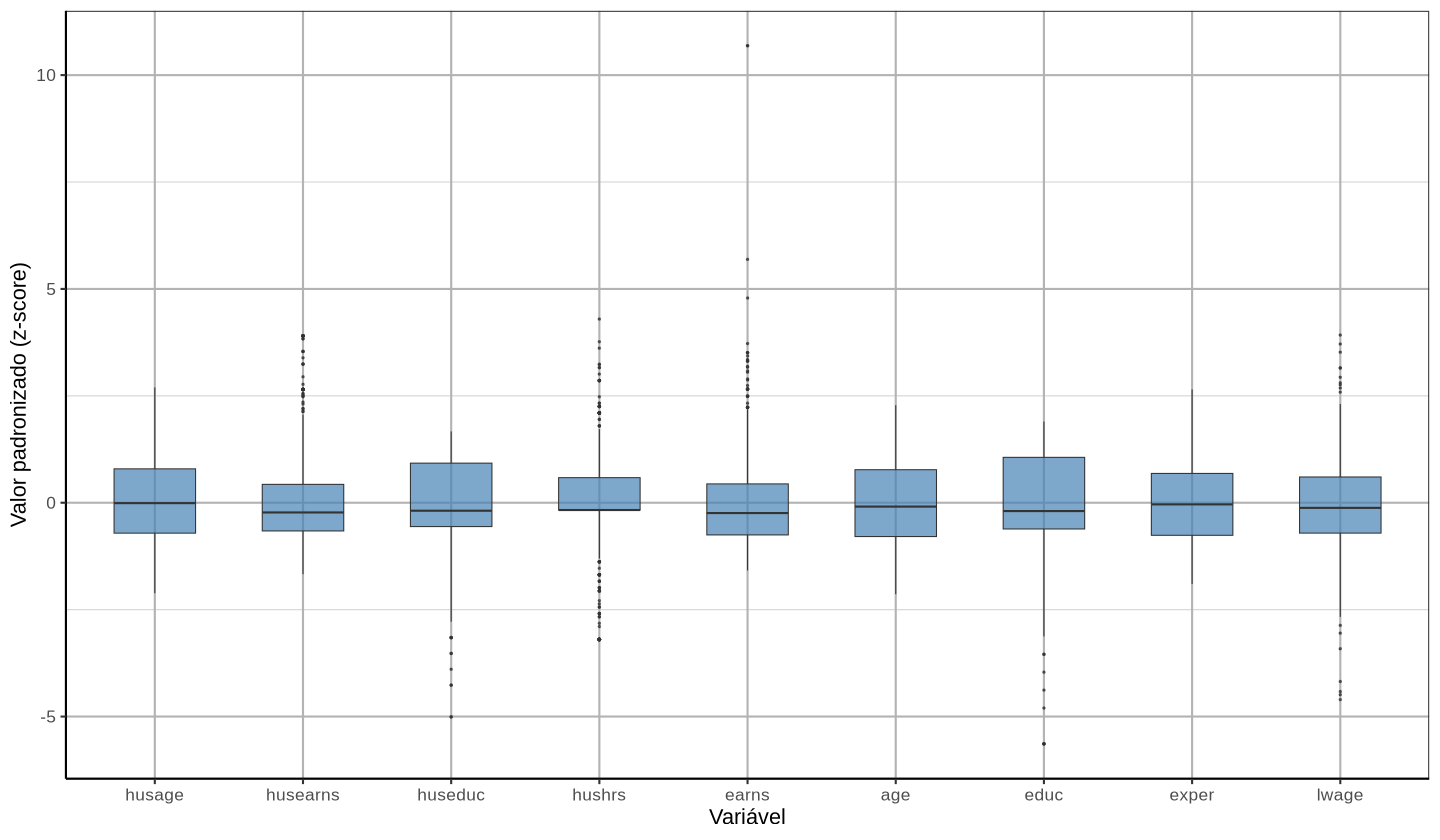

In [13]:
# Verificando os boxplots após a padronização, para confirmar que as variáveis numéricas estão na mesma escala.

 # Amplia só um pouco o tamanho do gráfico na saída do notebook
options(repr.plot.width = 12, repr.plot.height = 7)

test1[, c("husage", "husearns", "huseduc", "hushrs", "earns", "age", "educ", "exper", "lwage")] %>%  # escolhe colunas
  stack() %>%  # coloca em formato longo (variável/valor)
  ggplot(aes(x = ind, y = values)) +  # inicia o gráfico com um único eixo x e um único eixo y
  geom_boxplot(fill = "steelblue", alpha = 0.7, width = 0.55, linewidth = 0.3, outlier.size = 0.3) +  # desenha boxplots
  labs(x = "Variável", y = "Valor padronizado (z-score)") +  # rótulos dos eixos
  theme_bw(base_size = 13) +
  theme(
    axis.line = element_line(color = "black"),
    panel.grid.major = element_line(color = "grey70", linewidth = 0.6),
    panel.grid.minor = element_line(color = "grey85", linewidth = 0.35)
  )

In [14]:
###############################################################################
#                               REGRESSAO RIDGE                               #
###############################################################################

# A regressao Ridge "encolhe os valores dos coeficientes"

# Vamos guardar a matriz de dados de treinamento das 
# variaveis explicativas para o modelo em um objeto 
# chamado "x"
library(dplyr)

View(train1)

,husage,husearns,huseduc,hushrs,earns,age,educ,exper,lwage,husunion_0,⋯,kidge6_0,kidge6_1,black_0,black_1,hispanic_0,hispanic_1,union_0,union_1,kidlt6_0,kidlt6_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
2369,-1.11227857,-1.16855618,-2.0408595,-0.3215968,-0.7101031,-1.16799090,-1.8698485,-0.65845620,-1.04059341,1,⋯,1,0,1,0,0,1,1,0,0,1
1177,-0.31020404,-1.44973132,-0.5575410,-2.9704046,-0.6674872,-0.73681004,-0.6136305,-0.55508549,-0.75297339,1,⋯,0,1,0,1,1,0,1,0,1,0
1098,-1.11227857,-0.60620591,-0.5575410,-0.1702364,-0.8805668,-0.19783396,-0.6136305,-0.03823190,-1.01818124,1,⋯,0,1,1,0,1,0,1,0,1,0
1252,1.39420434,1.09564360,0.5549478,-0.3215968,-0.3734373,1.74247994,0.2238482,1.61569956,-0.18302060,0,⋯,1,0,1,0,1,0,1,0,1,0
634,0.09083323,0.34091034,-0.5575410,-0.1702364,0.5044506,-0.09003874,-0.6136305,0.06513881,0.23791160,1,⋯,1,0,1,0,1,0,1,0,0,1
2097,0.09083323,1.62543675,0.9257774,2.1001702,-0.2626359,0.01775648,-0.6136305,0.16850953,-0.01988423,1,⋯,0,1,1,0,1,0,1,0,1,0
1152,-1.01201925,-0.84298497,0.9257774,-0.1702364,-0.4970235,-0.52121961,-0.6136305,-0.34834405,-0.63614415,1,⋯,1,0,1,0,1,0,1,0,0,1
1327,0.29135186,1.61359779,1.6674366,-0.1702364,2.4434750,-0.19783396,1.4800663,-0.55508549,1.81770173,0,⋯,0,1,0,1,1,0,0,1,1,0
2072,-0.91175994,-1.05016665,-0.5575410,-0.1702364,-0.5566858,-0.73681004,1.8988056,-1.17530979,-0.48809125,1,⋯,1,0,1,0,1,0,1,0,1,0


In [15]:
# reordenando o dataset porque a coluna "lwage" esta no meio do dataset
train1 <- train1 %>% select(lwage, everything()) # train1 é a base de treino padronizada
View(train1)


,lwage,husage,husearns,huseduc,hushrs,earns,age,educ,exper,husunion_0,⋯,kidge6_0,kidge6_1,black_0,black_1,hispanic_0,hispanic_1,union_0,union_1,kidlt6_0,kidlt6_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
2369,-1.04059341,-1.11227857,-1.16855618,-2.0408595,-0.3215968,-0.7101031,-1.16799090,-1.8698485,-0.65845620,1,⋯,1,0,1,0,0,1,1,0,0,1
1177,-0.75297339,-0.31020404,-1.44973132,-0.5575410,-2.9704046,-0.6674872,-0.73681004,-0.6136305,-0.55508549,1,⋯,0,1,0,1,1,0,1,0,1,0
1098,-1.01818124,-1.11227857,-0.60620591,-0.5575410,-0.1702364,-0.8805668,-0.19783396,-0.6136305,-0.03823190,1,⋯,0,1,1,0,1,0,1,0,1,0
1252,-0.18302060,1.39420434,1.09564360,0.5549478,-0.3215968,-0.3734373,1.74247994,0.2238482,1.61569956,0,⋯,1,0,1,0,1,0,1,0,1,0
634,0.23791160,0.09083323,0.34091034,-0.5575410,-0.1702364,0.5044506,-0.09003874,-0.6136305,0.06513881,1,⋯,1,0,1,0,1,0,1,0,0,1
2097,-0.01988423,0.09083323,1.62543675,0.9257774,2.1001702,-0.2626359,0.01775648,-0.6136305,0.16850953,1,⋯,0,1,1,0,1,0,1,0,1,0
1152,-0.63614415,-1.01201925,-0.84298497,0.9257774,-0.1702364,-0.4970235,-0.52121961,-0.6136305,-0.34834405,1,⋯,1,0,1,0,1,0,1,0,0,1
1327,1.81770173,0.29135186,1.61359779,1.6674366,-0.1702364,2.4434750,-0.19783396,1.4800663,-0.55508549,0,⋯,0,1,0,1,1,0,0,1,1,0
2072,-0.48809125,-0.91175994,-1.05016665,-0.5575410,-0.1702364,-0.5566858,-0.73681004,1.8988056,-1.17530979,1,⋯,1,0,1,0,1,0,1,0,1,0


In [16]:

# Guardando os valores das variáveis explicativas em 'x'
# colunas 2 a última de train1 convertidas para uma matriz: é a matriz de preditores
x <- as.matrix(train1[,2:ncol(train1)])
ncol(train1)
View(x)

[1] 25

,husage,husearns,huseduc,hushrs,earns,age,educ,exper,husunion_0,husunion_1,⋯,kidge6_0,kidge6_1,black_0,black_1,hispanic_0,hispanic_1,union_0,union_1,kidlt6_0,kidlt6_1
2369,-1.11227857,-1.16855618,-2.0408595,-0.3215968,-0.7101031,-1.16799090,-1.8698485,-0.65845620,1,0,⋯,1,0,1,0,0,1,1,0,0,1
1177,-0.31020404,-1.44973132,-0.5575410,-2.9704046,-0.6674872,-0.73681004,-0.6136305,-0.55508549,1,0,⋯,0,1,0,1,1,0,1,0,1,0
1098,-1.11227857,-0.60620591,-0.5575410,-0.1702364,-0.8805668,-0.19783396,-0.6136305,-0.03823190,1,0,⋯,0,1,1,0,1,0,1,0,1,0
1252,1.39420434,1.09564360,0.5549478,-0.3215968,-0.3734373,1.74247994,0.2238482,1.61569956,0,1,⋯,1,0,1,0,1,0,1,0,1,0
634,0.09083323,0.34091034,-0.5575410,-0.1702364,0.5044506,-0.09003874,-0.6136305,0.06513881,1,0,⋯,1,0,1,0,1,0,1,0,0,1
2097,0.09083323,1.62543675,0.9257774,2.1001702,-0.2626359,0.01775648,-0.6136305,0.16850953,1,0,⋯,0,1,1,0,1,0,1,0,1,0
1152,-1.01201925,-0.84298497,0.9257774,-0.1702364,-0.4970235,-0.52121961,-0.6136305,-0.34834405,1,0,⋯,1,0,1,0,1,0,1,0,0,1
1327,0.29135186,1.61359779,1.6674366,-0.1702364,2.4434750,-0.19783396,1.4800663,-0.55508549,0,1,⋯,0,1,0,1,1,0,0,1,1,0
2072,-0.91175994,-1.05016665,-0.5575410,-0.1702364,-0.5566858,-0.73681004,1.8988056,-1.17530979,1,0,⋯,1,0,1,0,1,0,1,0,1,0
356,-1.11227857,-0.06161407,0.5549478,1.0406471,0.5257586,-1.27578612,0.6425876,-1.38205122,0,1,⋯,1,0,1,0,1,0,1,0,1,0


In [17]:
# Vamos guardar o vetor de dados de treinamento da 
# variavel dependente para o modelo em um objeto
# chamado "y_train"
y_train = train1$lwage
View(y_train)

[1]  -1.040593415  -0.752973389  -1.018181243  -0.183020601   0.237911604
   [6]  -0.019884232  -0.636144145   1.817701730  -0.488091253   0.256943486
  [11]   0.782700646   1.715312099   1.492264123  -1.132987994   1.837530868
  [16]   0.179638065  -1.132987994   2.260101140  -1.424906764  -0.448309886
  [21]   1.121579874  -0.468941961  -0.561336540   1.691788314  -1.250163788
  [26]  -1.311586583  -0.165626786  -0.636144145   0.192221831  -1.132987994
  [31]  -0.165626786  -0.429351859  -1.132987994  -0.365150977  -0.626457770
  [36]  -0.242932208   0.253911641   1.640197711   0.226399683  -0.242932208
  [41]   0.135851480  -0.073232207  -1.040593415  -1.690444126   0.747952785
  [46]   0.057421189  -0.636144145   1.009570147   0.179638065  -1.132987994
  [51]  -0.019884232   1.914836289   0.107258208  -0.365150977   0.052363064
  [56]   0.179638065  -0.657069747   1.672756432   1.239393852  -0.420046121
  [61]   0.379162255   1.331788431  -0.242932208   0.843684098  -0.630326639
  [66]  -0.150537629  -0.787723143   0.294444815   2.804890182  -1.440753410
  [71]   1.099054079   0.799838808   0.234082503  -0.787723143  -0.523053105
  [76]  -0.564673274   1.432630893  -0.242932208  -1.132987994  -0.365150977
  [81]  -0.019884232   0.694604810  -1.132987994  -0.495804373  -0.139300297
  [86]   0.540620788   0.365040788   1.239393852   0.158479535  -1.132987994
  [91]  -0.933465697   0.444308103   1.133695892   1.745136289   0.360128480
  [96]   0.456619174  -0.710415828   1.817701730   0.947475082   1.292741826
 [101]   1.212145120   0.524904809   0.602210231  -0.952497579   0.928443200
 [106]  -0.495804373   1.301488917  -0.952497579  -1.770171615   0.676481913
 [111]  -0.009393026   1.021748658   0.203163743  -0.365150977   1.196836291
 [116]  -0.242932208  -0.787723143   1.037135130  -0.242932208  -1.478254739
 [121]  -0.112280705   0.934807991   1.638006677  -0.588198953   0.071396840
 [126]  -1.132987994   2.095326704   0.276535909   0.602210231   0.947475082
 [131]  -0.030436038   0.006235842   0.379162255   0.569464031   0.602210231
 [136]  -0.019884232  -1.440753410  -0.091355104  -0.062441793   2.682673306
 [141]  -0.290877401  -0.495804373   1.212145120   0.126290090  -1.385860160
 [146]  -0.073232207   0.203163743   1.239393852  -1.132987994   0.062464164
 [151]  -1.112806624  -1.152019876  -0.436619955  -0.495804373  -1.332512185
 [156]  -0.495804373  -1.210293416  -0.462285536   1.099054079  -0.899448812
 [161]   0.740925191   0.524904809  -0.803569789  -0.710415828   0.179638065
 [166]   1.069693851  -0.365150977   1.914836289  -0.495804373  -1.077011536
 [171]  -0.213571979   0.602210231   0.658184795   1.146999272  -0.460071778
 [176]   0.701804732   0.602210231  -0.073232207  -0.105978406   0.174898084
 [181]   0.360128480  -0.112280705  -1.066535480   0.712553484  -0.495804373
 [186]   0.676481913   1.292741826   3.837399131  -0.710415828  -1.555560160
 [191]   0.947475082   1.127965497  -0.184660562   0.749509422   0.427768356
 [196]  -1.332512185  -1.205367851   0.009938064  -0.607230834  -1.385860160
 [201]   1.292741826   0.177178123  -2.631162593  -1.132987994   1.200347247
 [206]   0.179638065  -0.089535239   0.655558206   0.272032644   0.115439076
 [211]  -1.297762430   0.349338065   0.280213512  -0.365150977  -0.184660562
 [216]  -0.787723143  -1.132987994  -0.658120761  -0.242932208  -3.636023236
 [221]  -0.573109795   0.782700646   2.144186564  -0.630326639  -0.509378555
 [226]   0.994236700  -0.365150977  -0.242932208   0.229475083  -0.952497579
 [231]  -1.440753410  -0.242932208  -1.290890122  -0.952497579   0.294444815
 [236]  -0.242932208  -0.297827352  -0.733278705   1.099054079   2.682673306
 [241]  -0.592938933  -1.424906764  -1.132987994   0.402686040  -0.128127351
 [246]   0.947475082  -0.495804373   0.272032644   0.602210231   0.351500693
 [251]  -0.675393378  -0.974140900  -0.461056512   0.179638065  -0.495804373
 [256]   0.360128480  -0.529925413  -0.282802580   2.804890182   1.895804407

In [18]:
# reordenando o dataset porque a coluna "lwage" esta no meio do dataset
test1 <- test1 %>% select(lwage, everything()) # teste1 é a base de teste padronizada
View(test1)

,lwage,husage,husearns,huseduc,hushrs,earns,age,educ,exper,husunion_0,⋯,kidge6_0,kidge6_1,black_0,black_1,hispanic_0,hispanic_1,union_0,union_1,kidlt6_0,kidlt6_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
5,0.17963806,0.19109254,0.37050772,0.1841182,-0.1702364,-0.32655980,0.34114213,-0.6136305,0.4786217,1,⋯,0,1,1,0,1,0,1,0,1,0
7,1.41988427,-0.71124130,2.20554545,0.9257774,-0.1702364,1.67638843,-0.62901482,-0.6136305,-0.4517148,1,⋯,1,0,1,0,1,0,1,0,1,0
9,-0.49580437,-0.91175994,-0.78379021,-0.5575410,-0.1702364,-0.56094736,-0.84460525,0.6425876,-0.9685684,1,⋯,1,0,1,0,1,0,1,0,0,1
15,-0.10048094,-1.41305652,-0.25103732,0.1841182,-0.4729573,-0.13478816,-1.16799090,0.2238482,-1.1753098,1,⋯,1,0,1,0,1,0,1,0,1,0
18,0.78270065,-0.20994472,2.64950619,0.9257774,-0.1702364,0.73883820,0.01775648,1.0613269,-0.2449733,1,⋯,1,0,1,0,1,0,1,0,0,1
20,-0.24293221,1.39420434,-0.90217974,1.6674366,1.3433680,0.09959940,1.52688951,1.8988056,0.9954753,1,⋯,1,0,1,0,1,0,0,1,1,0
23,0.17963806,-0.20994472,-1.07976404,1.6674366,0.4352054,0.09959940,-0.19783396,1.0613269,-0.4517148,1,⋯,0,1,1,0,1,0,1,0,1,0
24,2.09532670,0.39161118,2.50151928,1.6674366,-0.1702364,3.08271379,0.77232299,1.8988056,0.2718802,1,⋯,0,1,1,0,1,0,1,0,1,0
28,2.58578493,-0.61098199,3.90147548,1.6674366,1.3433680,2.49461409,-0.52121961,1.8988056,-0.9685684,1,⋯,1,0,1,0,0,1,1,0,0,1


In [19]:
# Vamos guardar a matriz de dados de teste das variaveis
# explicativas para o modelo em um objeto chamado
# "x_test"
x_test = as.matrix(test1[,2:ncol(test1)]) # test1 é a base de teste padronizada
ncol(test1)
View(x_test)

[1] 25

,husage,husearns,huseduc,hushrs,earns,age,educ,exper,husunion_0,husunion_1,⋯,kidge6_0,kidge6_1,black_0,black_1,hispanic_0,hispanic_1,union_0,union_1,kidlt6_0,kidlt6_1
5,0.19109254,0.37050772,0.1841182,-0.1702364,-0.32655980,0.34114213,-0.6136305,0.4786217,1,0,⋯,0,1,1,0,1,0,1,0,1,0
7,-0.71124130,2.20554545,0.9257774,-0.1702364,1.67638843,-0.62901482,-0.6136305,-0.4517148,1,0,⋯,1,0,1,0,1,0,1,0,1,0
9,-0.91175994,-0.78379021,-0.5575410,-0.1702364,-0.56094736,-0.84460525,0.6425876,-0.9685684,1,0,⋯,1,0,1,0,1,0,1,0,0,1
15,-1.41305652,-0.25103732,0.1841182,-0.4729573,-0.13478816,-1.16799090,0.2238482,-1.1753098,1,0,⋯,1,0,1,0,1,0,1,0,1,0
18,-0.20994472,2.64950619,0.9257774,-0.1702364,0.73883820,0.01775648,1.0613269,-0.2449733,1,0,⋯,1,0,1,0,1,0,1,0,0,1
20,1.39420434,-0.90217974,1.6674366,1.3433680,0.09959940,1.52688951,1.8988056,0.9954753,1,0,⋯,1,0,1,0,1,0,0,1,1,0
23,-0.20994472,-1.07976404,1.6674366,0.4352054,0.09959940,-0.19783396,1.0613269,-0.4517148,1,0,⋯,0,1,1,0,1,0,1,0,1,0
24,0.39161118,2.50151928,1.6674366,-0.1702364,3.08271379,0.77232299,1.8988056,0.2718802,1,0,⋯,0,1,1,0,1,0,1,0,1,0
28,-0.61098199,3.90147548,1.6674366,1.3433680,2.49461409,-0.52121961,1.8988056,-0.9685684,1,0,⋯,1,0,1,0,0,1,1,0,0,1
29,1.29394502,-0.65060199,-0.5575410,-3.1974452,0.84963959,0.77232299,-0.6136305,0.8921045,1,0,⋯,1,0,1,0,1,0,1,0,1,0


In [20]:
# Vamos guardar o vetor de dados de teste da variavel
# dependente para o modelo em um objeto chamado "y_test"
y_test = test1$lwage

In [21]:
# Vamos calcular o valor otimo de lambda; 
# alpha = "0", eh para regressao Ridge
# Vamos testar os lambdas de 10^-3 ate 10^2, a cada 0.1
lambdas <- 10^seq(2, -3, by = -.1)
# Calculando o lambda:
ridge_lamb <- cv.glmnet(x, y_train, alpha = 0, # cross-validation para encontrar o melhor lambda
                        lambda = lambdas, standardize = FALSE) #standardize = TRUE por padrão, mas já padronizamos manualmente
# Vamos ver qual o lambda otimo 
best_lambda_ridge <- ridge_lamb$lambda.min
best_lambda_ridge

[1] 0.01995262

In [22]:
# Estimando o modelo Ridge
ridge_reg = glmnet(x, y_train, alpha = 0, 
                   family = 'gaussian', 
                   lambda = best_lambda_ridge,
                   standardize = FALSE) #standardize = TRUE por padrão, mas já padronizamos manualmente

# Vamos ver o resultado (valores) da estimativa 
# (coeficientes)
ridge_reg[["beta"]]

24 x 1 sparse Matrix of class "dgCMatrix"
                      s0
husage      0.0099111667
husearns    0.0710125625
huseduc     0.0273985029
hushrs     -0.0113108090
earns       0.7273060816
age         0.0285019596
educ        0.0706560715
exper       0.0007746172
husunion_0 -0.0154909076
husunion_1  0.0150815685
husblck_0  -0.0044448684
husblck_1   0.0044858944
hushisp_0  -0.0220557328
hushisp_1   0.0219845979
kidge6_0   -0.0113947860
kidge6_1    0.0104789673
black_0     0.0260636499
black_1    -0.0261071619
hispanic_0  0.0548603719
hispanic_1 -0.0548315508
union_0    -0.0616083914
union_1     0.0611747933
kidlt6_0   -0.0700644238
kidlt6_1    0.0681263153

In [23]:
# Vamos calcular o R^2 dos valores verdadeiros e 
# preditos conforme a seguinte funcao:
eval_results <- function(true, predicted, df) {
  SSE <- sum((predicted - true)^2)
  SST <- sum((true - mean(true))^2)
  R_square <- 1 - SSE / SST
  RMSE = sqrt(SSE/nrow(df))
  
# As metricas de performace do modelo:
  data.frame(
    RMSE = RMSE,
    Rsquare = R_square
  )
}

In [24]:
# Predicao e avaliacao nos dados de treinamento:
predictions_train <- predict(ridge_reg, # modelo estimado
                             s = best_lambda_ridge,
                             newx = x)



In [25]:
# As metricas da base de treinamento sao:
ridge_result_train <- eval_results(y_train, predictions_train, train1)
ridge_result_train

RMSE,Rsquare
<dbl>,<dbl>
0.5669669,0.6782986


In [26]:
# Predicao e avaliacao nos dados de teste:
predictions_test <- predict(ridge_reg, 
                            s = best_lambda_ridge, 
                            newx = x_test)



In [27]:

# As metricas da base de teste sao:
ridge_result_test <- eval_results(y_test, predictions_test, test1)
ridge_result_test
# Se compararmos as metricas de treinamento e teste
# vemos que o tamanho dos erros de treinamento e teste
# e os R^2 sao parecidos, o que descarta a hipotese
# de overfitting e underfitting. 

RMSE,Rsquare
<dbl>,<dbl>
0.5334179,0.7017385


In [28]:
# Como os valores do dataset sao padronizados, nos temos
# de padronizar tambem os dados que vamos fazer a predicao.
# Note que as variaveis dummies nao devem ser padronizadas.

# Valores fornecidos no enunciado
husage <- 40
husunion <- 0
husearns <- 600
huseduc <- 13
husblck <- 1
hushisp <- 0
hushrs <- 40
kidge6 <- 1
# 'earns' usará a média da variável 'earns' na base de treinamento,
# já que não foi fornecido um valor específico para essa variável no enunciado.
# Autorizado via email do professor Razer, dia 5 de Abril
earns <- mean(train$earns)
age <- 38
black <- 0
educ <- 13
hispanic <- 1
union <- 0
exper <- 18
kidlt6 <- 1


In [29]:
## Padronizando usando os mesmos parametros da base de treino

# As variaveis numericas serao padronizadas com media e desvio da base de treino
# As variaveis dummy (0/1) serao mantidas sem padronizacao

# Dummies: manter como estao
# husunion, husblck, hushisp, kidge6, black, hispanic, union, kidlt6

# Montar data.frame com a mesma ordem e nomes das colunas usadas no treino
# (as dummies foram criadas com sufixo _0 e _1 pelo fastDummies)

our_pred = as.matrix(data.frame(
  husage = (husage - mean(train$husage)) / sd(train$husage),
  husearns = (husearns - mean(train$husearns)) / sd(train$husearns),
  huseduc = (huseduc - mean(train$huseduc)) / sd(train$huseduc),
  hushrs = (hushrs - mean(train$hushrs)) / sd(train$hushrs),
  earns = (earns - mean(train$earns)) / sd(train$earns),
  age = (age - mean(train$age)) / sd(train$age),
  educ = (educ - mean(train$educ)) / sd(train$educ),
  exper = (exper - mean(train$exper)) / sd(train$exper),
  husunion_0 = as.integer(husunion == 0),
  husunion_1 = as.integer(husunion == 1),
  husblck_0 = as.integer(husblck == 0),
  husblck_1 = as.integer(husblck == 1),
  hushisp_0 = as.integer(hushisp == 0),
  hushisp_1 = as.integer(hushisp == 1),
  kidge6_0 = as.integer(kidge6 == 0),
  kidge6_1 = as.integer(kidge6 == 1),
  black_0 = as.integer(black == 0),
  black_1 = as.integer(black == 1),
  hispanic_0 = as.integer(hispanic == 0),
  hispanic_1 = as.integer(hispanic == 1),
  union_0 = as.integer(union == 0),
  union_1 = as.integer(union == 1),
  kidlt6_0 = as.integer(kidlt6 == 0), # se kidlt6 eh 0, kidlt6_0 eh 1; se kidlt6 eh 1, kidlt6_0 eh 0
  kidlt6_1 = as.integer(kidlt6 == 1) # se kidlt6 eh 1, kidlt6_1 eh 1; caso contrario, eh 0
))



In [30]:
# Fazendo a predicao:
predict_our_ridge <- predict(ridge_reg, 
                             s = best_lambda_ridge, 
                             newx = our_pred)
# O resultado da predicao eh:
predict_our_ridge

# s=0.1 -> o valor de lambda usado na predição 
# valor (na escala padronizada) -> 0.2340868

s=0.01995262
-0.0184961


In [31]:
# O resultado eh padronizado; primeiro voltamos para a escala de lwage
# e, como lwage ja eh o log do salario, aplicamos exp no final
lwage_pred_ridge_log <- (predict_our_ridge * sd(train$lwage) + mean(train$lwage))

# O resultado eh:
lwage_pred_ridge <- exp(lwage_pred_ridge_log)
lwage_pred_ridge
# Este eh o valor predito do salario nominal, segundo as caracteristicas que atribuimos


s=0.01995262
9.006603


In [32]:
# O intervalo de confianca contra a base de treino (nao havia sido padronizada ainda)
n <- nrow(train) # tamanho da amostra
m <- lwage_pred_ridge_log # valor medio predito
s <- sd(train$lwage) # desvio padrao
dam <- s/sqrt(n) # erro padrão da media
CIlwr_ridge_log <- m + (qnorm(0.025))*dam # intervalo inferior
CIupr_ridge_log <- m - (qnorm(0.025))*dam # intervalo superior

# Os valores sao:
CIlwr_ridge <- exp(CIlwr_ridge_log)
CIupr_ridge <- exp(CIupr_ridge_log)

CIlwr_ridge
CIupr_ridge



s=0.01995262
8.750477


s=0.01995262
9.270227


In [33]:
# Resumo final do Ridge (treino e teste)
ridge_result_train
ridge_result_test

RMSE,Rsquare
<dbl>,<dbl>
0.5669669,0.6782986


RMSE,Rsquare
<dbl>,<dbl>
0.5334179,0.7017385


In [34]:
###############################################################################
#           Unidade 2: Modelos de regularizacao ou penalidade                 #
#                         Secao 2.3: Regressao Lasso                          #
###############################################################################

library(glmnet)
library(dplyr)

# Reutilizando os objetos criados na secao de Ridge:
# train, test, train1, test1
dim(train1)
dim(test1)

[1] 1287   25

[1] 1287   25

In [35]:
# Reordenando para manter a variavel resposta na 1a coluna
train1 <- train1 %>% select(lwage, everything())
View(train1)

,lwage,husage,husearns,huseduc,hushrs,earns,age,educ,exper,husunion_0,⋯,kidge6_0,kidge6_1,black_0,black_1,hispanic_0,hispanic_1,union_0,union_1,kidlt6_0,kidlt6_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
2369,-1.04059341,-1.11227857,-1.16855618,-2.0408595,-0.3215968,-0.7101031,-1.16799090,-1.8698485,-0.65845620,1,⋯,1,0,1,0,0,1,1,0,0,1
1177,-0.75297339,-0.31020404,-1.44973132,-0.5575410,-2.9704046,-0.6674872,-0.73681004,-0.6136305,-0.55508549,1,⋯,0,1,0,1,1,0,1,0,1,0
1098,-1.01818124,-1.11227857,-0.60620591,-0.5575410,-0.1702364,-0.8805668,-0.19783396,-0.6136305,-0.03823190,1,⋯,0,1,1,0,1,0,1,0,1,0
1252,-0.18302060,1.39420434,1.09564360,0.5549478,-0.3215968,-0.3734373,1.74247994,0.2238482,1.61569956,0,⋯,1,0,1,0,1,0,1,0,1,0
634,0.23791160,0.09083323,0.34091034,-0.5575410,-0.1702364,0.5044506,-0.09003874,-0.6136305,0.06513881,1,⋯,1,0,1,0,1,0,1,0,0,1
2097,-0.01988423,0.09083323,1.62543675,0.9257774,2.1001702,-0.2626359,0.01775648,-0.6136305,0.16850953,1,⋯,0,1,1,0,1,0,1,0,1,0
1152,-0.63614415,-1.01201925,-0.84298497,0.9257774,-0.1702364,-0.4970235,-0.52121961,-0.6136305,-0.34834405,1,⋯,1,0,1,0,1,0,1,0,0,1
1327,1.81770173,0.29135186,1.61359779,1.6674366,-0.1702364,2.4434750,-0.19783396,1.4800663,-0.55508549,0,⋯,0,1,0,1,1,0,0,1,1,0
2072,-0.48809125,-0.91175994,-1.05016665,-0.5575410,-0.1702364,-0.5566858,-0.73681004,1.8988056,-1.17530979,1,⋯,1,0,1,0,1,0,1,0,1,0


In [36]:
# Matriz de preditores e vetor resposta da base de treino
x <- as.matrix(train1[, 2:ncol(train1)])
y_train <- train1$lwage

ncol(x)
length(y_train)

[1] 24

[1] 1287

In [37]:
# Reordenando a base de teste no mesmo formato da base de treino
test1 <- test1 %>% select(lwage, everything())

# Matriz de preditores e vetor resposta da base de teste
x_test <- as.matrix(test1[, 2:ncol(test1)])
y_test <- test1$lwage

dim(x_test)
length(y_test)

[1] 1287   24

[1] 1287

In [38]:
# Busca do melhor lambda via validacao cruzada
lambdas <- 10^seq(2, -3, by = -0.1)

lasso_lamb <- cv.glmnet(
  x, y_train,
  alpha = 1,
  lambda = lambdas,
  standardize = FALSE
)

best_lambda_lasso <- lasso_lamb$lambda.min
best_lambda_lasso

[1] 0.005011872

In [39]:
# Estimando o modelo Lasso
lasso_reg <- glmnet(
  x, y_train,
  alpha = 1,
  family = "gaussian",
  lambda = best_lambda_lasso,
  standardize = FALSE
)

# Coeficientes estimados
lasso_reg[["beta"]]

24 x 1 sparse Matrix of class "dgCMatrix"
                                 s0
husage      0.006033359089181010090
husearns    0.065650421132237041233
huseduc     0.025335041701548682846
hushrs     -0.004038184403095879810
earns       0.743067585484203929624
age         0.023678596366588536976
educ        0.067305525201695887150
exper       .                      
husunion_0 -0.010648750690886740408
husunion_1  0.000000000000003916737
husblck_0   .                      
husblck_1   .                      
hushisp_0   .                      
hushisp_1   .                      
kidge6_0    .                      
kidge6_1    .                      
black_0     .                      
black_1     .                      
hispanic_0  .                      
hispanic_1  .                      
union_0    -0.091394214551608649044
union_1     0.000000000000010321896
kidlt6_0   -0.094814684797099313407
kidlt6_1    .                      

In [40]:
# Predicoes e avaliacao nos dados de treinamento
predictions_train_lasso <- predict(
  lasso_reg,
  s = best_lambda_lasso,
  newx = x
)

lasso_result_train <- eval_results(y_train, predictions_train_lasso, train1)
lasso_result_train

RMSE,Rsquare
<dbl>,<dbl>
0.5680645,0.6770518


In [41]:
# Predicoes e avaliacao nos dados de teste
predictions_test_lasso <- predict(
  lasso_reg,
  s = best_lambda_lasso,
  newx = x_test
)

lasso_result_test <- eval_results(y_test, predictions_test_lasso, test1)
lasso_result_test

RMSE,Rsquare
<dbl>,<dbl>
0.5355721,0.6993245


In [42]:
# Vamos usar o mesmo perfil de predicao adotado na secao de Ridge
husage <- 40
husunion <- 0
husearns <- 600
huseduc <- 13
husblck <- 1
hushisp <- 0
hushrs <- 40
kidge6 <- 1
earns <- mean(train$earns)
age <- 38
black <- 0
educ <- 13
hispanic <- 1
union <- 0
exper <- 18
kidlt6 <- 1

In [43]:
# Monta a matriz de predicao com o mesmo padrao da Ridge
our_pred <- as.matrix(data.frame(
  husage = (husage - mean(train$husage)) / sd(train$husage),
  husearns = (husearns - mean(train$husearns)) / sd(train$husearns),
  huseduc = (huseduc - mean(train$huseduc)) / sd(train$huseduc),
  hushrs = (hushrs - mean(train$hushrs)) / sd(train$hushrs),
  earns = (earns - mean(train$earns)) / sd(train$earns),
  age = (age - mean(train$age)) / sd(train$age),
  educ = (educ - mean(train$educ)) / sd(train$educ),
  exper = (exper - mean(train$exper)) / sd(train$exper),
  husunion_0 = as.integer(husunion == 0),
  husunion_1 = as.integer(husunion == 1),
  husblck_0 = as.integer(husblck == 0),
  husblck_1 = as.integer(husblck == 1),
  hushisp_0 = as.integer(hushisp == 0),
  hushisp_1 = as.integer(hushisp == 1),
  kidge6_0 = as.integer(kidge6 == 0),
  kidge6_1 = as.integer(kidge6 == 1),
  black_0 = as.integer(black == 0),
  black_1 = as.integer(black == 1),
  hispanic_0 = as.integer(hispanic == 0),
  hispanic_1 = as.integer(hispanic == 1),
  union_0 = as.integer(union == 0),
  union_1 = as.integer(union == 1),
  kidlt6_0 = as.integer(kidlt6 == 0),
  kidlt6_1 = as.integer(kidlt6 == 1)
))



In [44]:
# Predicao com Lasso na escala padronizada de lwage
predict_our_lasso <- predict(
  lasso_reg,
  s = best_lambda_lasso,
  newx = our_pred
)
predict_our_lasso

s=0.005011872
0.03796337


In [45]:
# Convertendo para a escala original de salario
lwage_pred_lasso_log <- (predict_our_lasso * sd(train$lwage) + mean(train$lwage))
lwage_pred_lasso <- exp(lwage_pred_lasso_log)

lwage_pred_lasso

s=0.005011872
9.27917


In [46]:
# Intervalo de confianca para o valor predito (via escala log)
n <- nrow(train)
m <- lwage_pred_lasso_log
s <- sd(train$lwage)
dam <- s / sqrt(n)

CIlwr_lasso_log <- m + (qnorm(0.025)) * dam
CIupr_lasso_log <- m - (qnorm(0.025)) * dam

CIlwr_lasso <- exp(CIlwr_lasso_log)
CIupr_lasso <- exp(CIupr_lasso_log)

CIlwr_lasso
CIupr_lasso

s=0.005011872
9.015292


s=0.005011872
9.550771


In [47]:
# Resumo final do Lasso (treino e teste)
lasso_result_train
lasso_result_test

RMSE,Rsquare
<dbl>,<dbl>
0.5680645,0.6770518


RMSE,Rsquare
<dbl>,<dbl>
0.5355721,0.6993245


In [48]:
###############################################################################
#            Unidade 2: Modelos de regularizacao ou penalidade                #
#                     Secao 2.4: Regressao ElasticNet                         # 
###############################################################################

# Carregando os pacotes necessarios
library(plyr)
library(readr)
library(dplyr)
library(ggplot2)
library(repr)
library(glmnet)
library(caret)

# Vamos reutilizar a mesma base de dados da Ridge/Lasso
# (objetos: dat, train, test, train1, test1)

In [49]:
# Vamos visualizar parte da base padronizada
glimpse(train1)

Rows: 1,287
Columns: 25
$ lwage      <dbl> -1.04059341, -0.75297339, -1.01818124, -0.18302060, 0.23791…
$ husage     <dbl> -1.11227857, -0.31020404, -1.11227857, 1.39420434, 0.090833…
$ husearns   <dbl> -1.16855618, -1.44973132, -0.60620591, 1.09564360, 0.340910…
$ huseduc    <dbl> -2.0408595, -0.5575410, -0.5575410, 0.5549478, -0.5575410, …
$ hushrs     <dbl> -0.3215968, -2.9704046, -0.1702364, -0.3215968, -0.1702364,…
$ earns      <dbl> -0.7101031, -0.6674872, -0.8805668, -0.3734373, 0.5044506, …
$ age        <dbl> -1.16799090, -0.73681004, -0.19783396, 1.74247994, -0.09003…
$ educ       <dbl> -1.8698485, -0.6136305, -0.6136305, 0.2238482, -0.6136305, …
$ exper      <dbl> -0.65845620, -0.55508549, -0.03823190, 1.61569956, 0.065138…
$ husunion_0 <int> 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,…
$ husunion_1 <int> 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,…
$ husblck_0  <int> 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ husblck_1  <in

In [50]:
# As colunas dummy precisam continuar numericas para o glmnet.
str(train1)


'data.frame':	1287 obs. of  25 variables:
 $ lwage     : num  -1.041 -0.753 -1.018 -0.183 0.238 ...
 $ husage    : num  -1.1123 -0.3102 -1.1123 1.3942 0.0908 ...
 $ husearns  : num  -1.169 -1.45 -0.606 1.096 0.341 ...
 $ huseduc   : num  -2.041 -0.558 -0.558 0.555 -0.558 ...
 $ hushrs    : num  -0.322 -2.97 -0.17 -0.322 -0.17 ...
 $ earns     : num  -0.71 -0.667 -0.881 -0.373 0.504 ...
 $ age       : num  -1.168 -0.737 -0.198 1.742 -0.09 ...
 $ educ      : num  -1.87 -0.614 -0.614 0.224 -0.614 ...
 $ exper     : num  -0.6585 -0.5551 -0.0382 1.6157 0.0651 ...
 $ husunion_0: int  1 1 1 0 1 1 1 0 1 0 ...
 $ husunion_1: int  0 0 0 1 0 0 0 1 0 1 ...
 $ husblck_0 : int  1 0 1 1 1 1 1 0 1 1 ...
 $ husblck_1 : int  0 1 0 0 0 0 0 1 0 0 ...
 $ hushisp_0 : int  0 1 1 1 1 1 1 1 1 1 ...
 $ hushisp_1 : int  1 0 0 0 0 0 0 0 0 0 ...
 $ kidge6_0  : int  1 0 0 1 1 0 1 0 1 1 ...
 $ kidge6_1  : int  0 1 1 0 0 1 0 1 0 0 ...
 $ black_0   : int  1 0 1 1 1 1 1 0 1 1 ...
 $ black_1   : int  0 1 0 0 0 0 0 1 0 0

In [51]:
# Vamos checar as dimensoes das bases de treinamento e teste
dim(train1)
dim(test1)

[1] 1287   25

[1] 1287   25

In [52]:
# As bases train1 e test1 ja estao padronizadas com os mesmos parametros
# da secao de Ridge/Lasso.


In [53]:
# Conferindo rapidamente as primeiras linhas
head(train1)

,lwage,husage,husearns,huseduc,hushrs,earns,age,educ,exper,husunion_0,⋯,kidge6_0,kidge6_1,black_0,black_1,hispanic_0,hispanic_1,union_0,union_1,kidlt6_0,kidlt6_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
2369,-1.04059341,-1.11227857,-1.1685562,-2.0408595,-0.3215968,-0.7101031,-1.16799090,-1.8698485,-0.65845620,1,⋯,1,0,1,0,0,1,1,0,0,1
1177,-0.75297339,-0.31020404,-1.4497313,-0.5575410,-2.9704046,-0.6674872,-0.73681004,-0.6136305,-0.55508549,1,⋯,0,1,0,1,1,0,1,0,1,0
1098,-1.01818124,-1.11227857,-0.6062059,-0.5575410,-0.1702364,-0.8805668,-0.19783396,-0.6136305,-0.03823190,1,⋯,0,1,1,0,1,0,1,0,1,0
1252,-0.18302060,1.39420434,1.0956436,0.5549478,-0.3215968,-0.3734373,1.74247994,0.2238482,1.61569956,0,⋯,1,0,1,0,1,0,1,0,1,0
634,0.23791160,0.09083323,0.3409103,-0.5575410,-0.1702364,0.5044506,-0.09003874,-0.6136305,0.06513881,1,⋯,1,0,1,0,1,0,1,0,0,1
2097,-0.01988423,0.09083323,1.6254367,0.9257774,2.1001702,-0.2626359,0.01775648,-0.6136305,0.16850953,1,⋯,0,1,1,0,1,0,1,0,1,0


In [54]:
###############################################################################
#                              REGRESSAO ELASTICNET                           #
###############################################################################

# Elastic Net combina Ridge e Lasso e escolhe alpha e lambda por CV.

# Reordenando para manter a variavel resposta na 1a coluna
train1 <- train1 %>% select(lwage, everything())
test1 <- test1 %>% select(lwage, everything())

View(train1)

,lwage,husage,husearns,huseduc,hushrs,earns,age,educ,exper,husunion_0,⋯,kidge6_0,kidge6_1,black_0,black_1,hispanic_0,hispanic_1,union_0,union_1,kidlt6_0,kidlt6_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
2369,-1.04059341,-1.11227857,-1.16855618,-2.0408595,-0.3215968,-0.7101031,-1.16799090,-1.8698485,-0.65845620,1,⋯,1,0,1,0,0,1,1,0,0,1
1177,-0.75297339,-0.31020404,-1.44973132,-0.5575410,-2.9704046,-0.6674872,-0.73681004,-0.6136305,-0.55508549,1,⋯,0,1,0,1,1,0,1,0,1,0
1098,-1.01818124,-1.11227857,-0.60620591,-0.5575410,-0.1702364,-0.8805668,-0.19783396,-0.6136305,-0.03823190,1,⋯,0,1,1,0,1,0,1,0,1,0
1252,-0.18302060,1.39420434,1.09564360,0.5549478,-0.3215968,-0.3734373,1.74247994,0.2238482,1.61569956,0,⋯,1,0,1,0,1,0,1,0,1,0
634,0.23791160,0.09083323,0.34091034,-0.5575410,-0.1702364,0.5044506,-0.09003874,-0.6136305,0.06513881,1,⋯,1,0,1,0,1,0,1,0,0,1
2097,-0.01988423,0.09083323,1.62543675,0.9257774,2.1001702,-0.2626359,0.01775648,-0.6136305,0.16850953,1,⋯,0,1,1,0,1,0,1,0,1,0
1152,-0.63614415,-1.01201925,-0.84298497,0.9257774,-0.1702364,-0.4970235,-0.52121961,-0.6136305,-0.34834405,1,⋯,1,0,1,0,1,0,1,0,0,1
1327,1.81770173,0.29135186,1.61359779,1.6674366,-0.1702364,2.4434750,-0.19783396,1.4800663,-0.55508549,0,⋯,0,1,0,1,1,0,0,1,1,0
2072,-0.48809125,-0.91175994,-1.05016665,-0.5575410,-0.1702364,-0.5566858,-0.73681004,1.8988056,-1.17530979,1,⋯,1,0,1,0,1,0,1,0,1,0


In [55]:
# Matriz de preditores e vetor resposta da base de treino
x <- as.matrix(train1[, 2:ncol(train1)])
y_train <- train1$lwage

# Matriz de preditores e vetor resposta da base de teste
x_test <- as.matrix(test1[, 2:ncol(test1)])
y_test <- test1$lwage

In [56]:
dim(x)
length(y_train)
dim(x_test)
length(y_test)

[1] 1287   24

[1] 1287

[1] 1287   24

[1] 1287

In [57]:
# Vamos configurar o treinamento do modelo por 
# cross validation, com 10 folders, 5 repeticoes
# e busca aleatoria dos componentes das amostras
# de treinamento, o "verboseIter" eh soh para 
# mostrar o processamento.

# por que aqui foi usado trainControl ao inves de cv.glmnet?
# trainControl (usado com caret::train) permite buscar simultaneamente por alpha e lambda usando CV configurável
#
# cv.glmnet: faz cross‑validation eficiente sobre a sequência de lambda gerada pelo glmnet, 
#mas não escolhe alpha automaticamente.

train_cont <- trainControl(method = "repeatedcv",
                           number = 10,
                           repeats = 5,
                           search = "random",
                           verboseIter = TRUE)

# Nos nao temos o parametro "alpha", porque a regressao
# ElasticNet vai encontra-lo automaticamente, cujo valor
# estara entre 0 e 1 (para Ridge ==> alpha = 0; e
# para Lasso ==> alpha = 1).
# O parametro "lambda" tambem eh escolhido por
# cross-validation

In [58]:
# Vamos treinar o modelo

# No glmnet puro, voce eh obrigado a escolher um alpha fixo (ex: 0.5)
# modelo_en <- glmnet(X, y, alpha = 0.5)
# O glmnet puro eh excelente quando voce ja sabe o valor de alpha que quer usar 
# (0 para Ridge, 1 para Lasso, ou um valor fixo como 0.5).
# Mas o ElasticNet exige encontrar o melhor equilibrio de 
# dois parametros ao mesmo tempo:
# o alpha (o mix entre Ridge/Lasso) e o lambda (o tamanho da multa).

elastic_reg <- train(
  x = x,
  y = y_train,
  method = "glmnet",
  tuneLength = 10,
  trControl = train_cont,
  standardize = FALSE
)


+ Fold01.Rep1: alpha=0.6093, lambda=4.15042 
- Fold01.Rep1: alpha=0.6093, lambda=4.15042 
+ Fold01.Rep1: alpha=0.7784, lambda=0.03009 
- Fold01.Rep1: alpha=0.7784, lambda=0.03009 
+ Fold01.Rep1: alpha=0.5260, lambda=0.28703 
- Fold01.Rep1: alpha=0.5260, lambda=0.28703 
+ Fold01.Rep1: alpha=0.3881, lambda=4.53878 
- Fold01.Rep1: alpha=0.3881, lambda=4.53878 
+ Fold01.Rep1: alpha=0.7733, lambda=0.00291 
- Fold01.Rep1: alpha=0.7733, lambda=0.00291 
+ Fold01.Rep1: alpha=0.5603, lambda=0.01687 
- Fold01.Rep1: alpha=0.5603, lambda=0.01687 
+ Fold01.Rep1: alpha=0.2864, lambda=0.67654 
- Fold01.Rep1: alpha=0.2864, lambda=0.67654 
+ Fold01.Rep1: alpha=0.2174, lambda=0.23541 
- Fold01.Rep1: alpha=0.2174, lambda=0.23541 
+ Fold01.Rep1: alpha=0.4037, lambda=0.11235 
- Fold01.Rep1: alpha=0.4037, lambda=0.11235 
+ Fold01.Rep1: alpha=0.1692, lambda=3.30679 
- Fold01.Rep1: alpha=0.1692, lambda=3.30679 
+ Fold02.Rep1: alpha=0.6093, lambda=4.15042 
- Fold02.Rep1: alpha=0.6093, lambda=4.15042 
+ Fold02.R

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


Aggregating results
Selecting tuning parameters
Fitting alpha = 0.773, lambda = 0.00291 on full training set


In [59]:
# O melhor parametro alpha escolhido eh:
elastic_reg$bestTune


,alpha,lambda
,<dbl>,<dbl>
9,0.7733269,0.002910355


In [60]:
# E os parametros sao:
elastic_reg[["finalModel"]][["beta"]]

  [[ suppressing 84 column names ‘s0’, ‘s1’, ‘s2’ ... ]]



24 x 84 sparse Matrix of class "dgCMatrix"
                                                                        
husage     . .          .        .         .         .         .        
husearns   . .          .        .         .         .         .        
huseduc    . .          .        .         .         .         .        
hushrs     . .          .        .         .         .         .        
earns      . 0.05926377 0.115085 0.1675343 0.2167018 0.2626928 0.3056255
age        . .          .        .         .         .         .        
educ       . .          .        .         .         .         .        
exper      . .          .        .         .         .         .        
husunion_0 . .          .        .         .         .         .        
husunion_1 . .          .        .         .         .         .        
husblck_0  . .          .        .         .         .         .        
husblck_1  . .          .        .         .         .         .        
hushisp_

In [61]:
# Vamos fazer as predicoes e avaliar a performance do
# modelo

# Vamos fazer as predicoes no modelo de treinamento:
predictions_train <- predict(elastic_reg, x)

In [62]:
# Vamos calcular o R^2 dos valores verdadeiros e 
# preditos conforme a seguinte funcao:
eval_results <- function(true, predicted, df) {
  SSE <- sum((predicted - true)^2)
  SST <- sum((true - mean(true))^2)
  R_square <- 1 - SSE / SST
  RMSE = sqrt(SSE/nrow(df))
  
  # As metricas de performace do modelo:
  data.frame(
    RMSE = RMSE,
    Rsquare = R_square
  )
}



In [63]:
# As metricas de performance na base de treinamento
# sao:
elasticnet_result_train <- eval_results(y_train, predictions_train, train1) 
elasticnet_result_train

RMSE,Rsquare
<dbl>,<dbl>
0.5671777,0.6780593


In [64]:
# Vamos fazer as predicoes na base de teste
predictions_test <- predict(elastic_reg, x_test)

# As metricas de performance na base de teste sao:
elasticnet_result_test <- eval_results(y_test, predictions_test, test1)
elasticnet_result_test

RMSE,Rsquare
<dbl>,<dbl>
0.5347261,0.7002737


In [65]:
# Vamos agora fazer a predicao para o mesmo perfil usado na Ridge/Lasso

# Valores fornecidos no enunciado
husage <- 40
husunion <- 0
husearns <- 600
huseduc <- 13
husblck <- 1
hushisp <- 0
hushrs <- 40
kidge6 <- 1
# 'earns' usa a media da variavel 'earns' na base de treinamento
earns <- mean(train$earns)
age <- 38
black <- 0
educ <- 13
hispanic <- 1
union <- 0
exper <- 18
kidlt6 <- 1

# Monta a matriz de predicao com o mesmo padrao da Ridge/Lasso
our_pred <- as.matrix(data.frame(
  husage = (husage - mean(train$husage)) / sd(train$husage),
  husearns = (husearns - mean(train$husearns)) / sd(train$husearns),
  huseduc = (huseduc - mean(train$huseduc)) / sd(train$huseduc),
  hushrs = (hushrs - mean(train$hushrs)) / sd(train$hushrs),
  earns = (earns - mean(train$earns)) / sd(train$earns),
  age = (age - mean(train$age)) / sd(train$age),
  educ = (educ - mean(train$educ)) / sd(train$educ),
  exper = (exper - mean(train$exper)) / sd(train$exper),
  husunion_0 = as.integer(husunion == 0),
  husunion_1 = as.integer(husunion == 1),
  husblck_0 = as.integer(husblck == 0),
  husblck_1 = as.integer(husblck == 1),
  hushisp_0 = as.integer(hushisp == 0),
  hushisp_1 = as.integer(hushisp == 1),
  kidge6_0 = as.integer(kidge6 == 0),
  kidge6_1 = as.integer(kidge6 == 1),
  black_0 = as.integer(black == 0),
  black_1 = as.integer(black == 1),
  hispanic_0 = as.integer(hispanic == 0),
  hispanic_1 = as.integer(hispanic == 1),
  union_0 = as.integer(union == 0),
  union_1 = as.integer(union == 1),
  kidlt6_0 = as.integer(kidlt6 == 0),
  kidlt6_1 = as.integer(kidlt6 == 1)
) )

In [66]:
# Vamos fazer a predicao com base nos parametros que
# selecionamos
predict_our_elastic <- predict(elastic_reg, newdata = our_pred)
predict_our_elastic


s=0.002910355 
   0.01285169

In [67]:
# O resultado esta na escala padronizada de lwage; vamos retornar a escala original
lwage_pred_elastic_log <- (predict_our_elastic * sd(train$lwage) + mean(train$lwage))
lwage_pred_elastic <- exp(lwage_pred_elastic_log)
lwage_pred_elastic


s=0.002910355 
     9.156936

In [68]:
# Vamos criar o intervalo de confianca para o nosso
# exemplo (via escala log)
n <- nrow(train)
m <- lwage_pred_elastic_log
s <- sd(train$lwage)
dam <- s / sqrt(n)
CIlwr_elastic_log <- m + (qnorm(0.025)) * dam
CIupr_elastic_log <- m - (qnorm(0.025)) * dam

CIlwr_elastic <- exp(CIlwr_elastic_log)
CIupr_elastic <- exp(CIupr_elastic_log)

# Os valores minimo e maximo sao:
CIlwr_elastic
CIupr_elastic

###############################################################################


s=0.002910355 
     8.896534

s=0.002910355 
     9.424959

In [69]:
elasticnet_result_train
elasticnet_result_test

RMSE,Rsquare
<dbl>,<dbl>
0.5671777,0.6780593


RMSE,Rsquare
<dbl>,<dbl>
0.5347261,0.7002737


In [70]:
# Resultado final:
# Tabela com RMSE e R2 (base de teste)
model_metrics <- rbind(
  data.frame(Model = "Ridge", Dataset = "Teste", RMSE = ridge_result_test$RMSE, Rsquare = ridge_result_test$Rsquare),
  data.frame(Model = "Lasso", Dataset = "Teste", RMSE = lasso_result_test$RMSE, Rsquare = lasso_result_test$Rsquare),
  data.frame(Model = "ElasticNet", Dataset = "Teste", RMSE = elasticnet_result_test$RMSE, Rsquare = elasticnet_result_test$Rsquare)
 )

# ordena por RMSE decrescente
#model_metrics <- model_metrics[order(model_metrics$RMSE, -model_metrics$Rsquare), ] 
model_metrics

# Predicoes com intervalos de confianca
pred_table <- rbind(
  data.frame(Model = "Ridge", Predicao = as.numeric(lwage_pred_ridge), CI_Lower = as.numeric(CIlwr_ridge), CI_Upper = as.numeric(CIupr_ridge)),
  data.frame(Model = "Lasso", Predicao = as.numeric(lwage_pred_lasso), CI_Lower = as.numeric(CIlwr_lasso), CI_Upper = as.numeric(CIupr_lasso)),
  data.frame(Model = "ElasticNet", Predicao = as.numeric(lwage_pred_elastic), CI_Lower = as.numeric(CIlwr_elastic), CI_Upper = as.numeric(CIupr_elastic))
 )

#pred_table <- data.frame(
#  Model = c("Ridge", "Lasso", "ElasticNet"),
#  Predicao = c(as.numeric(lwage_pred_ridge), as.numeric(lwage_pred_lasso), as.numeric(lwage_pred_elastic)),
#  CI_Lower = c(as.numeric(CIlwr_ridge), as.numeric(CIlwr_lasso), as.numeric(CIlwr_elastic)),
#  CI_Upper = c(as.numeric(CIupr_ridge), as.numeric(CIupr_lasso), as.numeric(CIupr_elastic))
#)
pred_table


Model,Dataset,RMSE,Rsquare
<chr>,<chr>,<dbl>,<dbl>
Ridge,Teste,0.5334179,0.7017385
Lasso,Teste,0.5355721,0.6993245
ElasticNet,Teste,0.5347261,0.7002737


Model,Predicao,CI_Lower,CI_Upper
<chr>,<dbl>,<dbl>,<dbl>
Ridge,9.006603,8.750477,9.270227
Lasso,9.279170,9.015292,9.550771
ElasticNet,9.156936,8.896534,9.424959
